# <center> Module 4 -1: Regression <br>Linear Regression on the GPA Dataset </center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

In this notebook, we will perform Linear Regression on the GPA dataset. Always start Machine Learning by <b> Asking the Right Question! </b>

<br><center> Can we predict a University grade point average (GPA) for a student based on their High School GPA in a meaningful way? </center>

Note: model.score() now gives a score appropriate to a regression style of model. It is no longer accuracy, but returns the **coefficient of determination** of the prediction.

The coefficient of determination is defined as 1 minus the residual sum of squares((y_true - y_pred)** 2).sum() divided by the total sum of squares ((y_true - y_true.mean()) ** 2).sum(). 
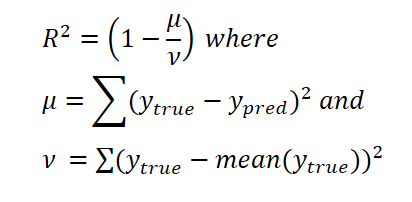
<br>The best possible score is 1.0 and the worst can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a score of 0.0.

## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

## Read csv file into a dataframe

In [6]:
df = pd.read_csv("../gpa.csv")

In [7]:
df.head(5)

,high_GPA,univ_GPA
0,3.45,3.52
1,2.78,2.91
2,2.52,2.40
3,3.67,3.47
4,3.24,3.47


In [8]:
df.describe()

,high_GPA,univ_GPA
count,105.000000,105.000000
mean,3.076381,3.172857
std,0.516598,0.447194
min,2.030000,2.080000
25%,2.670000,3.010000
50%,3.170000,3.290000
75%,3.480000,3.470000
max,4.000000,3.810000


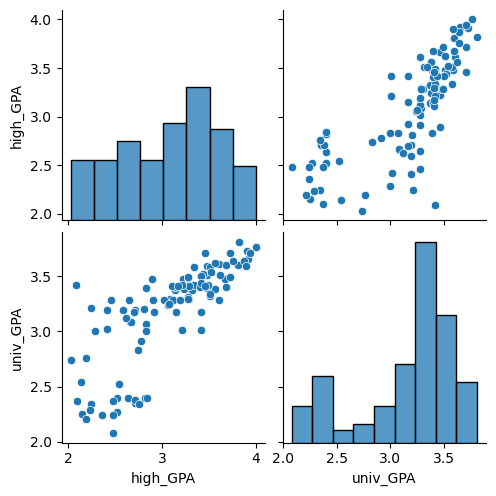

In [9]:
sn.pairplot(df)

## Create Input and Output Data

In [11]:
X = df.iloc[:,0:1].values
y = df.iloc[:,1:2].values

## Create Train and Test Sets

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=0)

## Linear Regression Modelling

### Train the LR Model

In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

### Evaluate the LR model

In [19]:
print(model.score(X_train, y_train).round(3))
scoreLR = model.score(X_test, y_test).round(3)
print(scoreLR)

0.616
0.573


In [31]:
from sklearn.metrics import mean_squared_error
import math

y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))
math.sqrt(mean_squared_error(y_test, y_pred))

0.09284716234231276


0.3047083233886347

In [33]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)

0.242411714035095

### Visualize the Linear Regression Relationship

*Note this is possible with simple code because only 1 X and 1 y

In [35]:
X_sorted = np.sort(X_train, axis = 0)

In [37]:
X_sorted

array([[2.03],
       [2.09],
       [2.1 ],
       [2.14],
       [2.15],
       [2.19],
       [2.19],
       [2.23],
       [2.24],
       [2.24],
       [2.29],
       [2.48],
       [2.48],
       [2.48],
       [2.52],
       [2.54],
       [2.59],
       [2.62],
       [2.65],
       [2.66],
       [2.67],
       [2.7 ],
       [2.71],
       [2.71],
       [2.71],
       [2.74],
       [2.76],
       [2.78],
       [2.81],
       [2.82],
       [2.83],
       [2.83],
       [2.89],
       [2.91],
       [2.92],
       [3.02],
       [3.06],
       [3.07],
       [3.09],
       [3.11],
       [3.12],
       [3.14],
       [3.15],
       [3.17],
       [3.21],
       [3.22],
       [3.24],
       [3.28],
       [3.28],
       [3.28],
       [3.29],
       [3.32],
       [3.34],
       [3.34],
       [3.41],
       [3.42],
       [3.42],
       [3.42],
       [3.42],
       [3.44],
       [3.45],
       [3.46],
       [3.48],
       [3.48],
       [3.48],
       [3.49],
       [3.

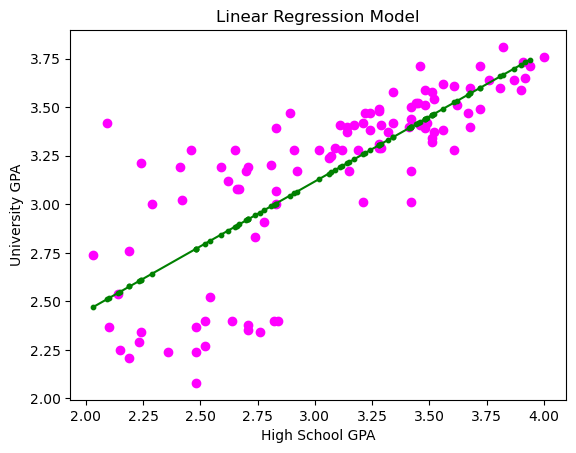

In [39]:
# Plot the provided points
plt.scatter(X, y, color = 'magenta')
predictions = model.predict(X_sorted)

# Draw a line based on the predicted values of X_train
plt.plot(X_sorted, predictions, color = 'green') 
plt.scatter(X_sorted, predictions, color = 'green', s = 10)


# Add details
plt.title('Linear Regression Model')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()

In [41]:
print(model.coef_)
print(model.intercept_)

#In other words, the equation of the line representing the model for this relationship is:
print(f"y = {model.coef_}X + {model.intercept_}")

[[0.66758336]]
[1.11445323]
y = [[0.66758336]]X + [1.11445323]


#### Make a Prediction!

In [43]:
new_GPA = 2.5
new = np.array((new_GPA), dtype=float).reshape(1,-1)
model.predict(new)

array([[2.78341162]])

#### OR use the equation of the line of best fit:

In [45]:
model.coef_* new_GPA + model.intercept_   # y = mx + b

array([[2.78341162]])

### Polynomial Estimator

An extra step for optimization is useful when trying the polynomial estimator. It is a good idea to compare different degrees of fit before selecting a model. The 'for loop' iterates through the desired range of degrees and trains a new model each time for comparison.

In [47]:
from sklearn.preprocessing import PolynomialFeatures
scoresPR = []
for i in range(1,6):
    poly=PolynomialFeatures(degree=i)
    x_poly = poly.fit_transform(X)
    
    x_trainp, x_testp, y_trainp, y_testp = train_test_split(x_poly, y, test_size=0.2, random_state=0)
    
    model = LinearRegression()
    model.fit(x_trainp, y_trainp)
    
    score = model.score(x_testp, y_testp)
    scoresPR.append(score)
    scorePR = max(scoresPR).round(3)

    
bestPoly = scoresPR.index(max(scoresPR)) + 1 # location of max score

print('Max polynomial score is: ',scorePR, "with a value of",bestPoly)

Max polynomial score is:  0.573 with a value of 1


In this case, the best degrees is 1. This is reasonable as there are only 2, highly linearly correlated features, as we could see in the scatter plot.

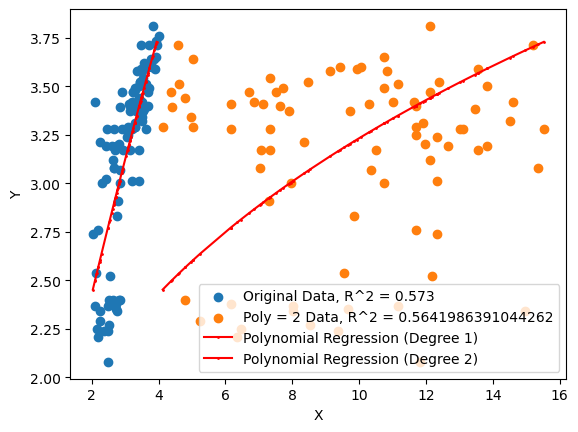

In [49]:
degree = 2
poly=PolynomialFeatures(degree=degree)
x_poly = poly.fit_transform(X)
    
x_trainp, x_testp, y_trainp, y_testp = train_test_split(x_poly, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(x_trainp, y_trainp)

#Generate predictions to plot
x_trainp = np.sort(x_trainp, axis = 0)
y_plot = model.predict(x_trainp)

# Plot the original data points
plt.plot(figsize = (10,10))
plt.scatter(X, y, label= f'Original Data, R^2 = {scorePR}')
plt.scatter(x_trainp[:,degree], y_trainp, label=f'Poly = {degree} Data, R^2 = {scoresPR[degree]}')

# Plot the curve of best fit
plt.plot(x_trainp[:,degree-1], y_plot, color='red', marker = '.', markersize = 2,label=f'Polynomial Regression (Degree {degree-1})')
plt.plot(x_trainp[:,degree], 
         y_plot, 
         color='red', 
         marker = '.', markersize = 2,
         label=f'Polynomial Regression (Degree {degree})')
# Add labels and legend
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# Show the plot
plt.show()